# ESP-Fi HAR Full Dataset (`Data_full_mat`) Overview + CSI Visualization

This notebook inspects the full `.mat` dataset layout, validates CSI sample format, creates signal plots, and visualizes sample-level embeddings with:
- class (`activity_id`) encoded by **color**
- environment encoded by **marker shape**


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.io as sio
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
def find_full_mat_root() -> Path:
    candidates = [
        Path('../ModelCode/Data_full_mat'),
        Path('ModelCode/Data_full_mat'),
        Path('../Data_full_mat'),
        Path('Data_full_mat'),
    ]

    for c in candidates:
        if c.exists() and any(c.glob('EnvironmentNo.*')):
            return c.resolve()

    raise FileNotFoundError(
        'Could not find Data_full_mat root. Tried: ' + ', '.join(str(x) for x in candidates)
    )


DATA_ROOT = find_full_mat_root()
DATA_ROOT


WindowsPath('C:/Users/stef4/Desktop/ZoeCare/ESP-Fi-HAR-experiments/ModelCode/Data_full_mat')

In [3]:
# Build manifest from Environment*/mat/*.mat
mat_files = sorted(DATA_ROOT.glob('EnvironmentNo.*/mat/*.mat'))
if not mat_files:
    # Handles folders with full-width parentheses in names
    mat_files = sorted(DATA_ROOT.rglob('mat/*.mat'))

if not mat_files:
    raise RuntimeError(f'No .mat files found under {DATA_ROOT}')

name_re = re.compile(r'^(?P<scene>\d+)-(?P<subject>\d+)-(?P<activity_id>\d+)-(?P<trial>\d+)\.mat$')
env_re = re.compile(r'EnvironmentNo\.(?P<env_id>\d+)')

rows = []
for p in mat_files:
    env_name = p.parent.parent.name
    m_name = name_re.match(p.name)
    m_env = env_re.search(env_name)

    if m_name is None:
        continue

    row = {
        'path': str(p.resolve()),
        'filename': p.name,
        'environment_name': env_name,
        'environment_id': int(m_env.group('env_id')) if m_env else np.nan,
        'scene': int(m_name.group('scene')),
        'subject': int(m_name.group('subject')),
        'activity_id': int(m_name.group('activity_id')),
        'trial': int(m_name.group('trial')),
    }
    rows.append(row)

manifest = pd.DataFrame(rows).sort_values(['environment_id', 'subject', 'activity_id', 'trial'])
manifest = manifest.reset_index(drop=True)

print(f'Data root: {DATA_ROOT}')
print(f'Total parsed .mat files: {len(manifest)}')
display(manifest.head(10))

display(
    manifest.groupby(['environment_name', 'activity_id'], as_index=False)
    .size()
    .rename(columns={'size': 'num_samples'})
    .sort_values(['environment_name', 'activity_id'])
)


Data root: C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-experiments\ModelCode\Data_full_mat
Total parsed .mat files: 2240


,path,filename,environment_name,environment_id,scene,subject,activity_id,trial
0,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-1.mat,EnvironmentNo.1(corridor),1,1,1,1,1
1,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-2.mat,EnvironmentNo.1(corridor),1,1,1,1,2
2,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-3.mat,EnvironmentNo.1(corridor),1,1,1,1,3
3,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-4.mat,EnvironmentNo.1(corridor),1,1,1,1,4
4,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-5.mat,EnvironmentNo.1(corridor),1,1,1,1,5
5,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-6.mat,EnvironmentNo.1(corridor),1,1,1,1,6
6,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-7.mat,EnvironmentNo.1(corridor),1,1,1,1,7
7,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-8.mat,EnvironmentNo.1(corridor),1,1,1,1,8
8,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-9.mat,EnvironmentNo.1(corridor),1,1,1,1,9
9,C:\Users\stef4\Desktop\ZoeCare\ESP-Fi-HAR-expe...,1-1-1-10.mat,EnvironmentNo.1(corridor),1,1,1,1,10


,environment_name,activity_id,num_samples
0,EnvironmentNo.1(corridor),1,80
1,EnvironmentNo.1(corridor),2,80
2,EnvironmentNo.1(corridor),3,80
3,EnvironmentNo.1(corridor),4,80
4,EnvironmentNo.1(corridor),5,80
5,EnvironmentNo.1(corridor),6,80
6,EnvironmentNo.1(corridor),7,80
7,EnvironmentNo.2（Office）,1,80
8,EnvironmentNo.2（Office）,2,80
9,EnvironmentNo.2（Office）,3,80


In [4]:
KEY_CANDIDATES = ['CSIamp', 'csi_amp', 'CSI_amp', 'amp']

def load_csi_amp(mat_path: Path, key_candidates=KEY_CANDIDATES):
    mat = sio.loadmat(str(mat_path))

    data = None
    used_key = None
    for key in key_candidates:
        if key in mat:
            data = np.asarray(mat[key], dtype=np.float32)
            used_key = key
            break

    if data is None:
        raise KeyError(f'No CSI amplitude key found in {mat_path}. Tried: {key_candidates}')

    # Normalize orientation to (time, subcarrier) = (950, 52)
    if data.shape == (52, 950):
        data = data.T
    elif data.ndim == 3 and data.shape[0] == 1 and data.shape[1:] == (950, 52):
        data = data[0]

    if data.shape != (950, 52):
        raise ValueError(f'Unexpected CSI shape {data.shape} in {mat_path}')

    visible_keys = sorted([k for k in mat.keys() if not k.startswith('__')])
    return data, used_key, visible_keys

sample_row = manifest.iloc[0]
sample_path = Path(sample_row['path'])
sample_x, used_key, visible_keys = load_csi_amp(sample_path)

print(f'Sample file: {sample_path.name}')
print(f'Environment: {sample_row.environment_name}')
print(f'Activity ID: {sample_row.activity_id}')
print(f'Loaded key: {used_key}')
print(f'Keys in .mat: {visible_keys}')
print(f'Shape (time, subcarrier): {sample_x.shape}')
print(f'Dtype: {sample_x.dtype}')
print(f'Min/Max: {sample_x.min():.4f} / {sample_x.max():.4f}')
print(f'Mean/Std: {sample_x.mean():.4f} / {sample_x.std():.4f}')


Sample file: 1-1-1-1.mat
Environment: EnvironmentNo.1(corridor)
Activity ID: 1
Loaded key: CSIamp
Keys in .mat: ['CSIamp']
Shape (time, subcarrier): (950, 52)
Dtype: float32
Min/Max: 28.1603 / 101.6366
Mean/Std: 57.5252 / 8.5759


 Sampling is around ~100 Hz, and 950 indices is roughly ~9.5–10 seconds.

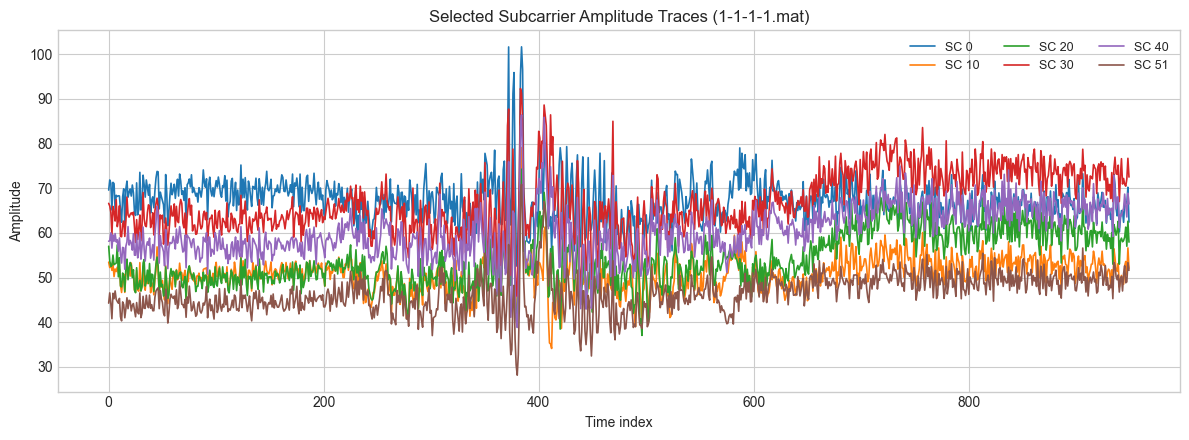

In [5]:
# Time-series for selected subcarriers
time_idx = np.arange(sample_x.shape[0])
selected_subcarriers = np.linspace(0, sample_x.shape[1] - 1, 6, dtype=int)

fig, ax = plt.subplots(figsize=(12, 4.5))
for sc in selected_subcarriers:
    ax.plot(time_idx, sample_x[:, sc], linewidth=1.2, label=f'SC {sc}')

ax.set_title(f'Selected Subcarrier Amplitude Traces ({sample_path.name})')
ax.set_xlabel('Time index')
ax.set_ylabel('Amplitude')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


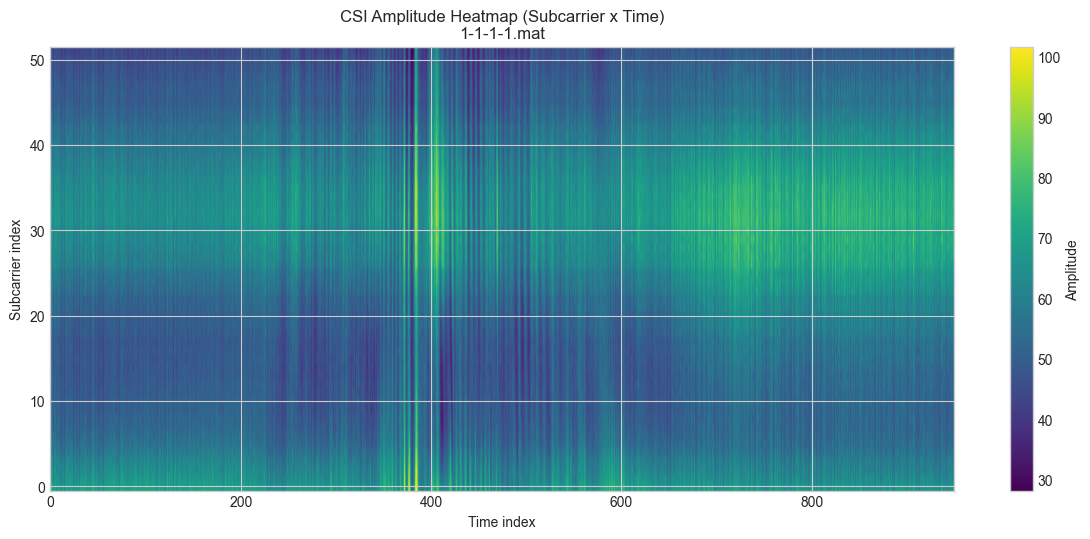

In [6]:
# Heatmap over time for each subcarrier
fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(sample_x.T, aspect='auto', origin='lower', cmap='viridis')

ax.set_title(f'CSI Amplitude Heatmap (Subcarrier x Time)\n{sample_path.name}')
ax.set_xlabel('Time index')
ax.set_ylabel('Subcarrier index')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Amplitude')
plt.tight_layout()
plt.show()


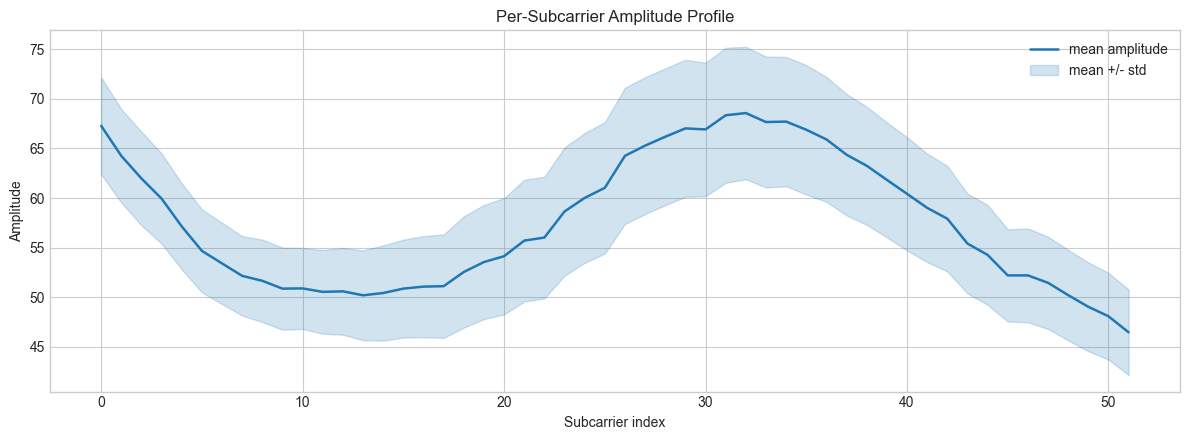

In [7]:
# Per-subcarrier statistics
sub_idx = np.arange(sample_x.shape[1])
sub_mean = sample_x.mean(axis=0)
sub_std = sample_x.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(sub_idx, sub_mean, color='tab:blue', linewidth=1.8, label='mean amplitude')
ax.fill_between(sub_idx, sub_mean - sub_std, sub_mean + sub_std, color='tab:blue', alpha=0.2, label='mean +/- std')

ax.set_title('Per-Subcarrier Amplitude Profile')
ax.set_xlabel('Subcarrier index')
ax.set_ylabel('Amplitude')
ax.legend()
plt.tight_layout()
plt.show()


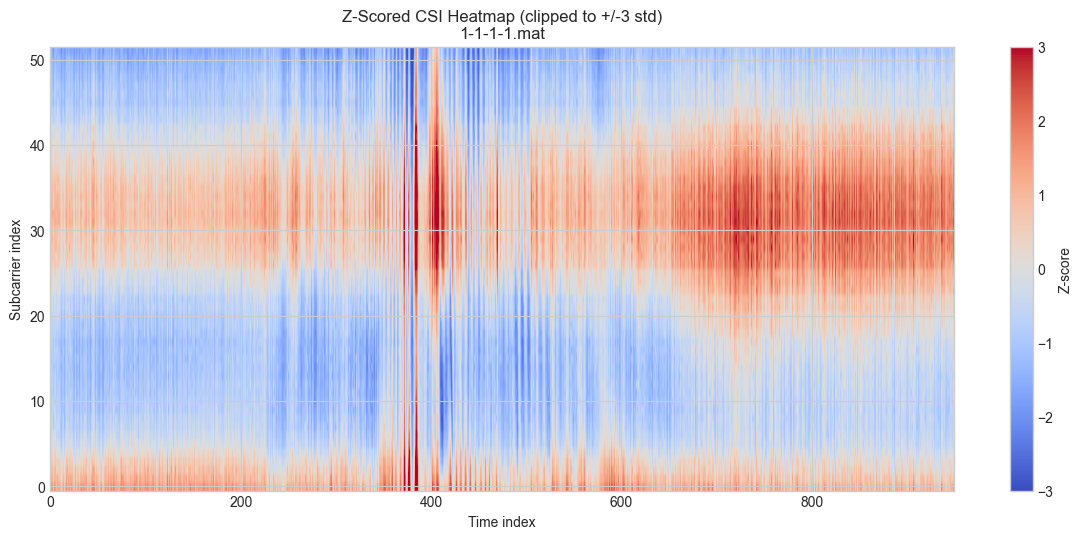

In [8]:
# Optional: normalized view matching training-time Z-score normalization
sample_x_norm = (sample_x - sample_x.mean()) / (sample_x.std() + 1e-8)

fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(sample_x_norm.T, aspect='auto', origin='lower', cmap='coolwarm', vmin=-3, vmax=3)

ax.set_title(f'Z-Scored CSI Heatmap (clipped to +/-3 std)\n{sample_path.name}')
ax.set_xlabel('Time index')
ax.set_ylabel('Subcarrier index')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Z-score')
plt.tight_layout()
plt.show()


## PCA and t-SNE of Multiple Samples

This section loads many CSI samples, flattens each sample (`950x52 -> 49400`), applies per-sample Z-score, and projects into 2D.

- Color = class (`activity_id`)
- Marker shape = environment

In [9]:
RANDOM_STATE = 42
MAX_SAMPLES_FOR_EMBEDDING = 1200  # increase if you want all samples

manifest_embed = manifest.copy()
if len(manifest_embed) > MAX_SAMPLES_FOR_EMBEDDING:
    # Balanced-ish sampling across (environment, activity) groups
    groups = []
    grouped = manifest_embed.groupby(['environment_name', 'activity_id'])
    per_group = max(1, MAX_SAMPLES_FOR_EMBEDDING // grouped.ngroups)

    for _, g in grouped:
        take_n = min(len(g), per_group)
        groups.append(g.sample(n=take_n, random_state=RANDOM_STATE))

    manifest_embed = pd.concat(groups, axis=0).drop_duplicates().reset_index(drop=True)
    if len(manifest_embed) > MAX_SAMPLES_FOR_EMBEDDING:
        manifest_embed = manifest_embed.sample(n=MAX_SAMPLES_FOR_EMBEDDING, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Embedding samples: {len(manifest_embed)}')
display(
    manifest_embed.groupby(['environment_name', 'activity_id'], as_index=False)
    .size()
    .rename(columns={'size': 'num_samples'})
    .sort_values(['environment_name', 'activity_id'])
)


Embedding samples: 1176


,environment_name,activity_id,num_samples
0,EnvironmentNo.1(corridor),1,42
1,EnvironmentNo.1(corridor),2,42
2,EnvironmentNo.1(corridor),3,42
3,EnvironmentNo.1(corridor),4,42
4,EnvironmentNo.1(corridor),5,42
5,EnvironmentNo.1(corridor),6,42
6,EnvironmentNo.1(corridor),7,42
7,EnvironmentNo.2（Office）,1,42
8,EnvironmentNo.2（Office）,2,42
9,EnvironmentNo.2（Office）,3,42


In [10]:
features = []
meta_rows = []

for i, row in manifest_embed.iterrows():
    x, _, _ = load_csi_amp(Path(row['path']))
    x = (x - x.mean()) / (x.std() + 1e-8)  # per-sample normalization
    features.append(x.reshape(-1).astype(np.float32))
    meta_rows.append(row)

    if (i + 1) % 200 == 0:
        print(f'Loaded {i + 1}/{len(manifest_embed)} samples')

X = np.stack(features, axis=0)
meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

print('Feature matrix shape:', X.shape)


Loaded 200/1176 samples
Loaded 400/1176 samples
Loaded 600/1176 samples
Loaded 800/1176 samples
Loaded 1000/1176 samples
Feature matrix shape: (1176, 49400)


In [11]:
# PCA 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X)
print('PCA explained variance ratio:', pca_2d.explained_variance_ratio_)

# t-SNE 2D (run on PCA-reduced features for speed/stability)
pre_dims = min(50, X.shape[1], X.shape[0] - 1)
X_pre = PCA(n_components=pre_dims, random_state=RANDOM_STATE).fit_transform(X)

n_samples = X.shape[0]
perplexity = min(30, max(5, (n_samples - 1) // 3))
if perplexity >= n_samples:
    perplexity = max(2, n_samples - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init='pca',
    learning_rate='auto',
    n_iter=1000,
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_pre)

print(f't-SNE perplexity used: {perplexity}')


PCA explained variance ratio: [0.27638972 0.18420203]
t-SNE perplexity used: 30


C:\Users\stef4\AppData\Local\Temp\ipykernel_12888\3873131453.py:64: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
C:\Users\stef4\AppData\Local\Temp\ipykernel_12888\3873131453.py:64: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from current font.
  plt.tight_layout()
c:\Users\stef4\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\stef4\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


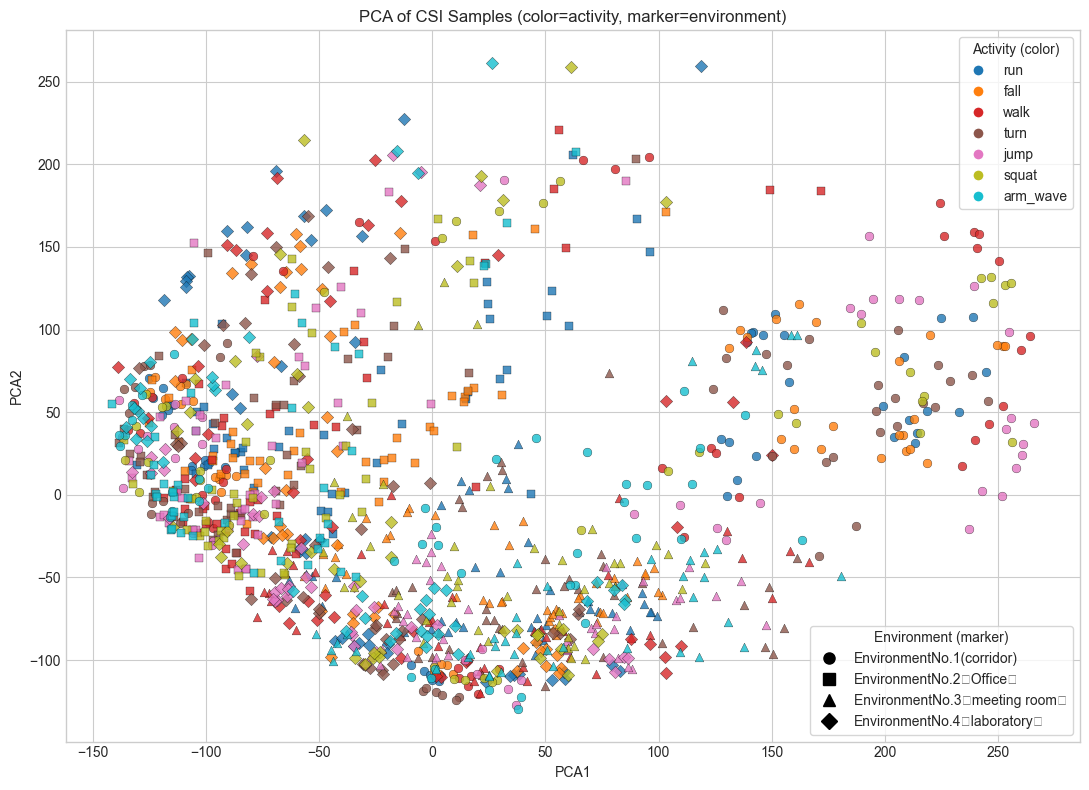

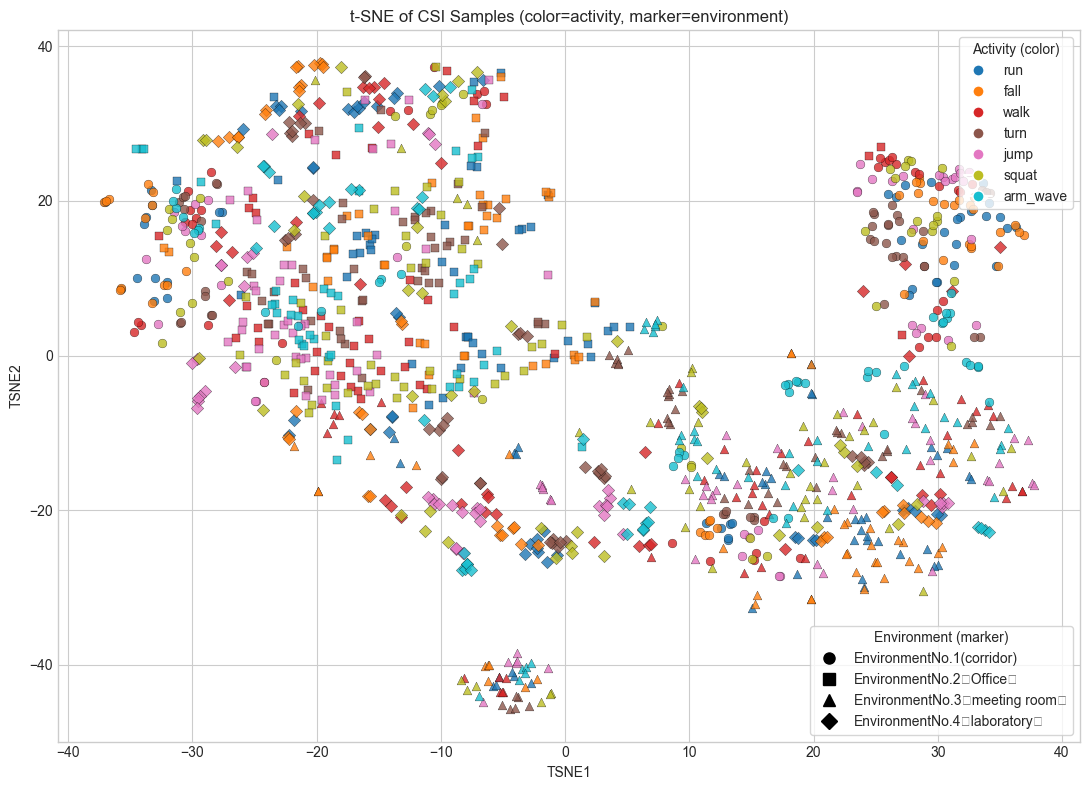

In [12]:
embed_df = meta_df[['activity_id', 'environment_name']].copy()
embed_df['PCA1'] = X_pca[:, 0]
embed_df['PCA2'] = X_pca[:, 1]
embed_df['TSNE1'] = X_tsne[:, 0]
embed_df['TSNE2'] = X_tsne[:, 1]

activity_name_map = {
    1: 'run',
    2: 'fall',
    3: 'walk',
    4: 'turn',
    5: 'jump',
    6: 'squat',
    7: 'arm_wave',
}

activity_ids = sorted(embed_df['activity_id'].unique())
environments = sorted(embed_df['environment_name'].unique())

colors = plt.cm.tab10(np.linspace(0, 1, max(len(activity_ids), 3)))
color_map = {act: colors[i] for i, act in enumerate(activity_ids)}
marker_pool = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
marker_map = {env: marker_pool[i % len(marker_pool)] for i, env in enumerate(environments)}

def activity_label(act_id: int) -> str:
    return activity_name_map.get(act_id, f'activity_{act_id}')


def plot_embedding(df, x_col, y_col, title):
    fig, ax = plt.subplots(figsize=(11, 8))

    for act in activity_ids:
        for env in environments:
            mask = (df['activity_id'] == act) & (df['environment_name'] == env)
            if mask.any():
                ax.scatter(
                    df.loc[mask, x_col],
                    df.loc[mask, y_col],
                    color=color_map[act],
                    marker=marker_map[env],
                    s=40,
                    alpha=0.80,
                    edgecolor='black',
                    linewidth=0.25,
                )

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    class_handles = [
        Line2D([0], [0], marker='o', color='w', label=activity_label(act), markerfacecolor=color_map[act], markersize=8)
        for act in activity_ids
    ]
    env_handles = [
        Line2D([0], [0], marker=marker_map[env], color='black', label=env, linestyle='None', markersize=8)
        for env in environments
    ]

    legend1 = ax.legend(handles=class_handles, title='Activity (color)', loc='upper right', frameon=True)
    ax.add_artist(legend1)
    ax.legend(handles=env_handles, title='Environment (marker)', loc='lower right', frameon=True)

    plt.tight_layout()
    plt.show()


plot_embedding(embed_df, 'PCA1', 'PCA2', 'PCA of CSI Samples (color=activity, marker=environment)')
plot_embedding(embed_df, 'TSNE1', 'TSNE2', 't-SNE of CSI Samples (color=activity, marker=environment)')



## Feature engineering & RF
Next instead of using the raw csi amptitudes, we will produce some features and check the performance:

In [13]:
import seaborn as sns
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score


In [14]:
# Build df_windows from manifest (one full CSI matrix = one window)
DEFAULT_FS_HZ = 100.0
MAX_WINDOWS_FOR_FEATURES = 1200  # set to None to use all
RANDOM_STATE = 42

ACTIVITY_NAME_MAP = {
    1: 'run',
    2: 'fall',
    3: 'walk',
    4: 'turn',
    5: 'jump',
    6: 'squat',
    7: 'arm_wave',
}

def estimate_sampling_freq_hz_from_csv(csv_path: Path):
    if not csv_path.exists():
        return np.nan
    try:
        # local_timestamp is typically in microseconds for ESP logs
        tmp = pd.read_csv(csv_path, usecols=['type', 'local_timestamp'])
        tmp = tmp[tmp['type'] == 'CSI_DATA']
        lt = pd.to_numeric(tmp['local_timestamp'], errors='coerce').dropna().to_numpy()
        if lt.size < 3:
            return np.nan
        d = np.diff(lt)
        d = d[d > 0]
        if d.size == 0:
            return np.nan
        med = float(np.median(d))
        if med <= 0:
            return np.nan
        return 1e6 / med
    except Exception:
        return np.nan

manifest_feat = manifest.copy()
if MAX_WINDOWS_FOR_FEATURES is not None and len(manifest_feat) > MAX_WINDOWS_FOR_FEATURES:
    groups = []
    grouped = manifest_feat.groupby(['environment_name', 'activity_id'])
    per_group = max(1, MAX_WINDOWS_FOR_FEATURES // grouped.ngroups)
    for _, g in grouped:
        take_n = min(len(g), per_group)
        groups.append(g.sample(n=take_n, random_state=RANDOM_STATE))
    manifest_feat = pd.concat(groups, axis=0).drop_duplicates().reset_index(drop=True)
    if len(manifest_feat) > MAX_WINDOWS_FOR_FEATURES:
        manifest_feat = manifest_feat.sample(n=MAX_WINDOWS_FOR_FEATURES, random_state=RANDOM_STATE).reset_index(drop=True)

rows = []
for i, row in manifest_feat.iterrows():
    mat_path = Path(row['path'])
    csi, _, _ = load_csi_amp(mat_path)

    csv_path = mat_path.parent.parent / 'csv' / (mat_path.stem + '.csv')
    fs = estimate_sampling_freq_hz_from_csv(csv_path)
    if not np.isfinite(fs) or fs <= 0:
        fs = DEFAULT_FS_HZ

    label = ACTIVITY_NAME_MAP.get(int(row['activity_id']), f"activity_{int(row['activity_id'])}")

    rows.append({
        'window_id': i,
        'record_id': mat_path.stem,
        'experiment_id': row.get('environment_id', np.nan),
        'source_file': str(mat_path),
        'label': label,
        'activity_id': int(row['activity_id']),
        'subject_id': int(row['subject']),
        'scene_id': int(row['scene']),
        'trial_id': int(row['trial']),
        'environment_name': row['environment_name'],
        'window_idx': 0,
        'sampling_freq_hz': float(fs),
        'window_sec': float(csi.shape[0] / fs),
        'csi_window_clean': csi.astype(np.float32),
    })

    if (i + 1) % 200 == 0:
        print(f'Loaded windows: {i + 1}/{len(manifest_feat)}')

df_windows = pd.DataFrame(rows)
print('df_windows shape:', df_windows.shape)
display(
    df_windows[
        ['window_id', 'record_id', 'environment_name', 'subject_id', 'activity_id', 'label', 'sampling_freq_hz', 'window_sec']
    ].head()
)



Loaded windows: 200/1176
Loaded windows: 400/1176
Loaded windows: 600/1176
Loaded windows: 800/1176
Loaded windows: 1000/1176
df_windows shape: (1176, 14)


,window_id,record_id,environment_name,subject_id,activity_id,label,sampling_freq_hz,window_sec
0,0,1-4-1-1,EnvironmentNo.1(corridor),4,1,run,99.990001,9.500950
1,1,1-1-1-1,EnvironmentNo.1(corridor),1,1,run,100.015002,9.498575
2,2,1-3-1-3,EnvironmentNo.1(corridor),3,1,run,99.980004,9.501900
3,3,1-4-1-2,EnvironmentNo.1(corridor),4,1,run,100.000000,9.500000
4,4,1-2-1-9,EnvironmentNo.1(corridor),2,1,run,99.990001,9.500950


In [15]:
EPS = 1e-8
SIGNAL_COL = 'csi_window_clean'

def to_2d(x):
    a = np.asarray(x, dtype=float)
    a = np.squeeze(a)
    if a.ndim == 1:
        a = a[:, None]
    if a.ndim != 2:
        raise ValueError(f'Expected 2D signal, got shape={a.shape}')
    return a

def safe_entropy_1d(x, bins=16):
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    h, _ = np.histogram(x, bins=min(bins, max(4, x.size // 2)))
    p = h.astype(float) / max(h.sum(), 1)
    return -np.sum(p * np.log(p + EPS))

def skew_kurt(x):
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    mu = x.mean()
    sd = x.std()
    z = (x - mu) / (sd + EPS)
    return np.mean(z ** 3), np.mean(z ** 4) - 3.0

def spectrum_features(sig, fs, prefix):
    y = np.asarray(sig, dtype=float).ravel()
    out = {
        f'{prefix}_dom_freq_hz': np.nan,
        f'{prefix}_spec_centroid_hz': np.nan,
        f'{prefix}_spec_entropy': np.nan,
        f'{prefix}_spectral_spread': np.nan,
        f'{prefix}_spectral_rolloff85_hz': np.nan,
        f'{prefix}_spectral_flatness': np.nan,
        f'{prefix}_low_freq_energy': np.nan,
        f'{prefix}_mid_freq_energy': np.nan,
        f'{prefix}_high_freq_energy': np.nan,
        f'{prefix}_low_mid_ratio': np.nan,
        f'{prefix}_low_high_ratio': np.nan,
        f'{prefix}_mid_high_ratio': np.nan,
    }
    if y.size < 4 or not np.isfinite(fs) or fs <= 0:
        return out

    y = y - y.mean()
    ps = np.abs(np.fft.rfft(y)) ** 2
    freqs = np.fft.rfftfreq(y.size, d=1.0 / fs)
    if ps.size <= 1:
        return out

    ps[0] = 0.0
    total = ps.sum() + EPS
    p = ps / total

    nyq = fs / 2.0
    f_low = min(0.5, nyq)
    f_mid = min(2.0, nyq)
    f_high = min(6.0, nyq)

    low_m = (freqs >= 0.0) & (freqs < f_low)
    mid_m = (freqs >= f_low) & (freqs < f_mid)
    high_m = (freqs >= f_mid) & (freqs <= f_high)

    low_e = ps[low_m].sum()
    mid_e = ps[mid_m].sum()
    high_e = ps[high_m].sum()

    centroid = np.sum(freqs * p)
    spread = np.sqrt(np.sum(((freqs - centroid) ** 2) * p))
    csum = np.cumsum(ps)
    ridx = np.searchsorted(csum, 0.85 * csum[-1]) if csum[-1] > 0 else 0
    roll85 = freqs[min(ridx, len(freqs) - 1)]
    flatness = np.exp(np.mean(np.log(ps + EPS))) / (np.mean(ps + EPS))
    dom = freqs[np.argmax(ps)]
    ent = -np.sum(p * np.log(p + EPS))

    out.update({
        f'{prefix}_dom_freq_hz': dom,
        f'{prefix}_spec_centroid_hz': centroid,
        f'{prefix}_spec_entropy': ent,
        f'{prefix}_spectral_spread': spread,
        f'{prefix}_spectral_rolloff85_hz': roll85,
        f'{prefix}_spectral_flatness': flatness,
        f'{prefix}_low_freq_energy': low_e,
        f'{prefix}_mid_freq_energy': mid_e,
        f'{prefix}_high_freq_energy': high_e,
        f'{prefix}_low_mid_ratio': low_e / (mid_e + EPS),
        f'{prefix}_low_high_ratio': low_e / (high_e + EPS),
        f'{prefix}_mid_high_ratio': mid_e / (high_e + EPS),
    })
    return out

def pairwise_corr_features(csi):
    T, S = csi.shape
    out = {
        'mean_pairwise_corr': np.nan,
        'std_pairwise_corr': np.nan,
        'ref_subcarrier_corr_mean': np.nan,
        'ref_subcarrier_corr_max_abs': np.nan,
        'corr_mean_abs': np.nan,
        'corr_eig1_ratio': np.nan,
    }
    if S < 2 or T < 3:
        return out

    C = np.corrcoef(csi, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

    iu = np.triu_indices(S, 1)
    vals = C[iu]
    if vals.size == 0:
        return out

    sub_var = np.var(csi, axis=0)
    ref_idx = int(np.argmax(sub_var))
    ref_vals = np.delete(C[ref_idx, :], ref_idx)

    eigvals = np.linalg.eigvalsh(C)
    eig1_ratio = eigvals[-1] / (eigvals.sum() + EPS)

    out.update({
        'mean_pairwise_corr': float(np.mean(vals)),
        'std_pairwise_corr': float(np.std(vals)),
        'ref_subcarrier_corr_mean': float(np.mean(ref_vals)),
        'ref_subcarrier_corr_max_abs': float(np.max(np.abs(ref_vals))),
        'corr_mean_abs': float(np.mean(np.abs(vals))),
        'corr_eig1_ratio': float(eig1_ratio),
    })
    return out

def pca_time_features(csi, fs):
    T, S = csi.shape
    out = {
        'pc1_var': np.nan,
        'pc2_var': np.nan,
        'pc1_energy': np.nan,
        'pc2_energy': np.nan,
        'pc1_dom_freq_hz': np.nan,
        'pc1_entropy': np.nan,
        'pc1_pc2_var_ratio': np.nan,
        'pc1_pc2_energy_ratio': np.nan,
        'pc1_explained_ratio': np.nan,
        'pc2_explained_ratio': np.nan,
    }
    if min(T, S) < 2:
        return out

    X = csi - csi.mean(axis=0, keepdims=True)
    U, Sv, Vt = np.linalg.svd(X, full_matrices=False)
    scores = U * Sv
    pc1 = scores[:, 0]
    pc2 = scores[:, 1] if scores.shape[1] > 1 else np.zeros_like(pc1)

    pc1_var = float(np.var(pc1))
    pc2_var = float(np.var(pc2))
    pc1_energy = float(np.mean(pc1 ** 2))
    pc2_energy = float(np.mean(pc2 ** 2))
    pc1_ent = safe_entropy_1d(pc1)
    pc1_dom = spectrum_features(pc1, fs, prefix='tmp')['tmp_dom_freq_hz']

    e = Sv ** 2
    e_sum = e.sum() + EPS
    pc1_exp = float(e[0] / e_sum)
    pc2_exp = float(e[1] / e_sum) if e.size > 1 else 0.0

    out.update({
        'pc1_var': pc1_var,
        'pc2_var': pc2_var,
        'pc1_energy': pc1_energy,
        'pc2_energy': pc2_energy,
        'pc1_dom_freq_hz': pc1_dom,
        'pc1_entropy': pc1_ent,
        'pc1_pc2_var_ratio': pc1_var / (pc2_var + EPS),
        'pc1_pc2_energy_ratio': pc1_energy / (pc2_energy + EPS),
        'pc1_explained_ratio': pc1_exp,
        'pc2_explained_ratio': pc2_exp,
    })
    return out

# Extra features beyond requested set
def autocorr_features_1d(x):
    x = np.asarray(x, dtype=float).ravel()
    x = x - np.mean(x)
    denom = np.sum(x * x) + EPS
    out = {'acf_lag1': np.nan, 'acf_lag5': np.nan, 'acf_lag10': np.nan}
    for lag in [1, 5, 10]:
        if x.size > lag:
            out[f'acf_lag{lag}'] = float(np.sum(x[:-lag] * x[lag:]) / denom)
    return out

def profile_shape_features(profile):
    p = np.asarray(profile, dtype=float).ravel()
    if p.size < 2:
        return {'profile_slope': np.nan, 'profile_roughness': np.nan, 'profile_entropy': np.nan}
    idx = np.arange(p.size, dtype=float)
    slope = float(np.polyfit(idx, p, deg=1)[0])
    rough = float(np.mean(np.abs(np.diff(p))))
    ent = float(safe_entropy_1d(p, bins=12))
    return {'profile_slope': slope, 'profile_roughness': rough, 'profile_entropy': ent}

def extract_features(row):
    csi = to_2d(row[SIGNAL_COL])
    fs = float(row['sampling_freq_hz']) if np.isfinite(row['sampling_freq_hz']) else np.nan

    amp_all = csi.ravel()
    mean_t = csi.mean(axis=1)
    profile = csi.mean(axis=0)

    mean_amp = float(np.mean(amp_all))
    std_amp = float(np.std(amp_all))
    median_amp = float(np.median(amp_all))
    iqr_amp = float(np.percentile(amp_all, 75) - np.percentile(amp_all, 25))
    min_amp = float(np.min(amp_all))
    max_amp = float(np.max(amp_all))
    range_amp = max_amp - min_amp
    skew_amp, kurt_amp = skew_kurt(amp_all)

    d = np.diff(mean_t)
    ad = np.abs(d)
    temporal_diff_mean = float(np.mean(ad)) if ad.size else 0.0
    temporal_diff_std = float(np.std(ad)) if ad.size else 0.0
    temporal_diff_rms = float(np.sqrt(np.mean(ad ** 2))) if ad.size else 0.0
    temporal_diff_energy = float(np.mean(ad ** 2)) if ad.size else 0.0
    temporal_diff_peak = float(np.max(ad)) if ad.size else 0.0
    motion_thr = float(np.mean(ad) + np.std(ad)) if ad.size else np.nan
    motion_ratio = float(np.mean(ad > motion_thr)) if ad.size else 0.0

    z = (mean_t - np.mean(mean_t)) / (np.std(mean_t) + EPS)
    if z.size >= 3:
        peaks = (z[1:-1] > z[:-2]) & (z[1:-1] >= z[2:]) & (z[1:-1] > 0.75)
        peak_count = int(np.sum(peaks))
    else:
        peak_count = 0
    duration = float(row['window_sec']) if np.isfinite(row['window_sec']) and row['window_sec'] > 0 else np.nan
    peak_density = peak_count / duration if np.isfinite(duration) else np.nan

    sub_var = np.var(csi, axis=0)
    thr = max(np.percentile(sub_var, 10) * 0.5, EPS)
    active = sub_var > thr
    active_count = int(np.sum(active))
    active_ratio = float(active_count / csi.shape[1]) if csi.shape[1] else np.nan
    k = max(1, int(np.ceil(0.10 * csi.shape[1])))
    topk_var_mean = float(np.mean(np.sort(sub_var)[-k:]))

    out = {
        'window_id': row['window_id'],
        'record_id': row['record_id'],
        'experiment_id': row['experiment_id'],
        'source_file': row['source_file'],
        'label': row['label'],
        'activity_id': row['activity_id'],
        'subject_id': row['subject_id'],
        'scene_id': row['scene_id'],
        'trial_id': row['trial_id'],
        'environment_name': row['environment_name'],
        'window_idx': row['window_idx'],
        'sampling_freq_hz': row['sampling_freq_hz'],
        'profile': profile,

        'mean_amp': mean_amp,
        'std_amp': std_amp,
        'median_amp': median_amp,
        'iqr_amp': iqr_amp,
        'min_amp': min_amp,
        'max_amp': max_amp,
        'range_amp': range_amp,
        'skew_amp': skew_amp,
        'kurt_amp': kurt_amp,

        'energy': float(np.mean(amp_all ** 2)),
        'temporal_diff_mean': temporal_diff_mean,
        'temporal_diff_std': temporal_diff_std,
        'temporal_diff_rms': temporal_diff_rms,
        'temporal_diff_energy': temporal_diff_energy,
        'temporal_diff_peak': temporal_diff_peak,
        'motion_ratio_above_thr': motion_ratio,
        'temporal_peak_count': peak_count,
        'temporal_peak_density': peak_density,

        'subcarrier_std_mean': float(np.mean(np.std(csi, axis=0))),
        'time_std_mean': float(np.mean(np.std(csi, axis=1))),
        'cv_amp': std_amp / (mean_amp + EPS),
        'log_energy': np.log1p(max(float(np.mean(amp_all ** 2)), 0.0)),
        'temporal_to_spatial_ratio': temporal_diff_mean / (float(np.mean(np.std(csi, axis=0))) + EPS),
        'active_subcarrier_count': active_count,
        'active_subcarrier_ratio': active_ratio,
        'topk_var_subcarrier_mean': topk_var_mean,
    }

    out.update(spectrum_features(mean_t, fs, prefix='time'))
    out.update(pairwise_corr_features(csi))
    out.update(pca_time_features(csi, fs))

    # Extra features
    out.update(autocorr_features_1d(mean_t))
    out.update(profile_shape_features(profile))

    return pd.Series(out)

df_features = df_windows.apply(extract_features, axis=1).copy()

meta_cols = [
    'window_id', 'record_id', 'experiment_id', 'source_file', 'label', 'activity_id',
    'subject_id', 'scene_id', 'trial_id', 'environment_name', 'window_idx', 'profile'
]
feature_cols = [
    c for c in df_features.columns
    if c not in meta_cols and pd.api.types.is_numeric_dtype(df_features[c])
]

print('df_features shape:', df_features.shape)
print('Number of numeric features:', len(feature_cols))
display(df_features[['label', 'environment_name', 'subject_id'] + feature_cols[:8]].head())



df_features shape: (1176, 73)
Number of numeric features: 61


,label,environment_name,subject_id,sampling_freq_hz,mean_amp,std_amp,median_amp,iqr_amp,min_amp,max_amp,range_amp
0,run,EnvironmentNo.1(corridor),4,99.990001,65.050505,9.546231,63.788715,12.981853,8.246211,178.196518,169.950307
1,run,EnvironmentNo.1(corridor),1,100.015002,57.525190,8.575898,56.364883,12.338440,28.160255,101.636604,73.476349
2,run,EnvironmentNo.1(corridor),3,99.980004,37.731891,25.420881,26.076809,35.159657,0.000000,167.836227,167.836227
3,run,EnvironmentNo.1(corridor),4,100.000000,64.754887,10.028145,63.253460,12.563820,39.012817,177.485214,138.472397
4,run,EnvironmentNo.1(corridor),2,99.990001,58.520608,11.616721,56.753853,16.259174,6.324555,157.610275,151.285720


## PCA and t-SNE on Engineered Features

This view projects each sample from `df_features` into 2D.
- Color encodes **action** (`label`)
- Marker shape encodes **environment** (`environment_name`)


PCA explained variance ratio: [0.24372397 0.17758084]
t-SNE perplexity: 30


C:\Users\stef4\AppData\Local\Temp\ipykernel_12888\2448315491.py:94: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
C:\Users\stef4\AppData\Local\Temp\ipykernel_12888\2448315491.py:94: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from current font.
  plt.tight_layout()
c:\Users\stef4\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\stef4\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


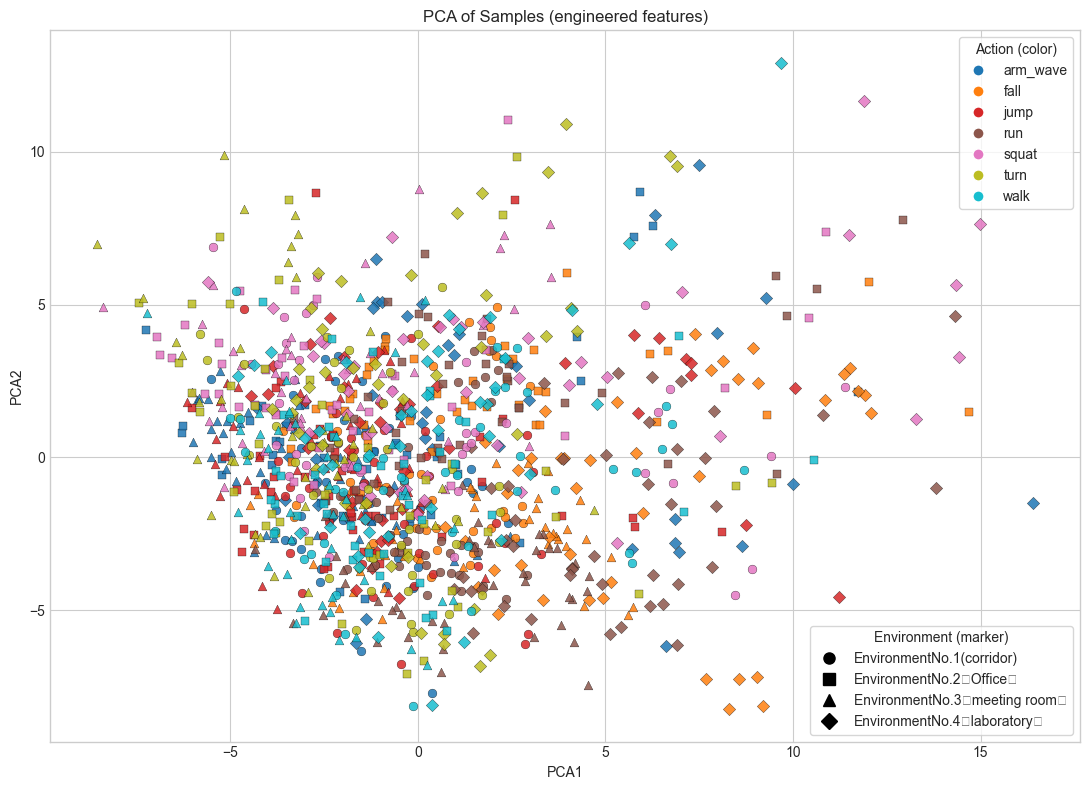

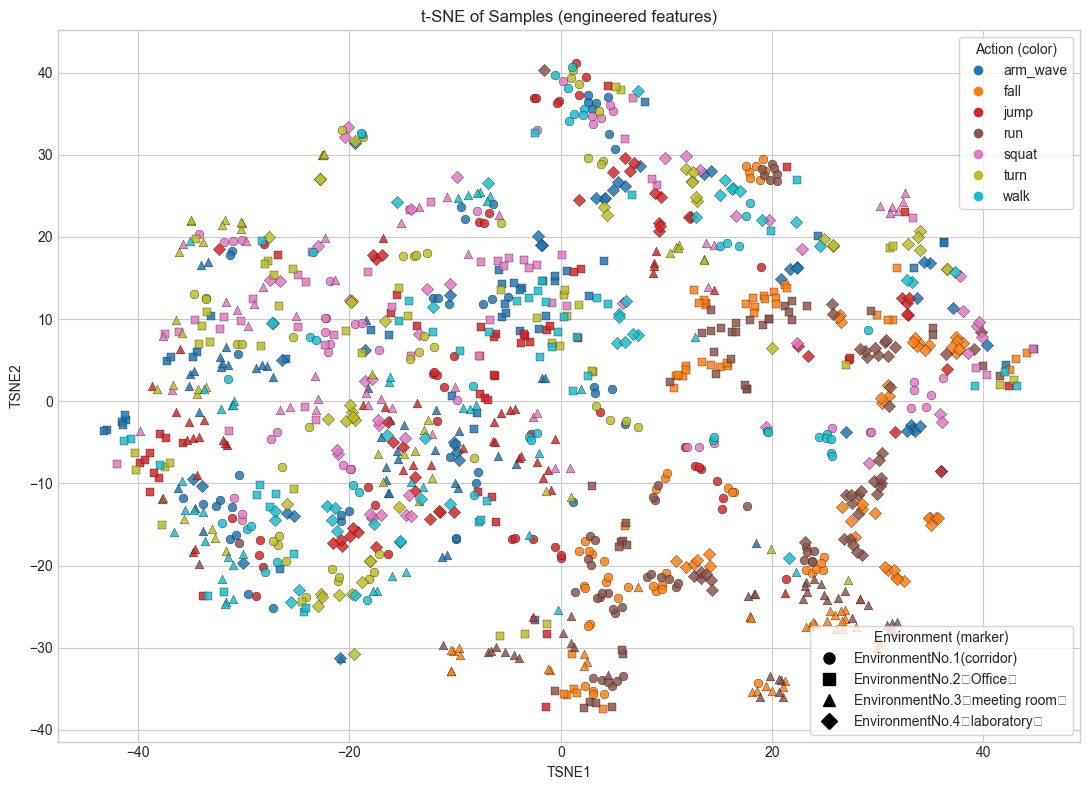

In [16]:
from sklearn.preprocessing import StandardScaler

# PCA/t-SNE sample visualization from engineered feature vectors
MAX_SAMPLES_FOR_VIS = 1200
RANDOM_STATE = 42

vis_df = df_features.copy()
if len(vis_df) > MAX_SAMPLES_FOR_VIS:
    vis_df = (
        vis_df.groupby(['environment_name', 'label'], group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), max(1, MAX_SAMPLES_FOR_VIS // (vis_df['environment_name'].nunique() * vis_df['label'].nunique()))), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )
    if len(vis_df) > MAX_SAMPLES_FOR_VIS:
        vis_df = vis_df.sample(n=MAX_SAMPLES_FOR_VIS, random_state=RANDOM_STATE).reset_index(drop=True)

X_vis = vis_df[feature_cols].replace([np.inf, -np.inf], np.nan)
imp_vis = SimpleImputer(strategy='median')
X_vis = imp_vis.fit_transform(X_vis)
X_vis = StandardScaler().fit_transform(X_vis)

# PCA
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_vis = pca_vis.fit_transform(X_vis)
print('PCA explained variance ratio:', pca_vis.explained_variance_ratio_)

# t-SNE on pre-reduced PCA features for speed/stability
pre_dims = min(30, X_vis.shape[1], X_vis.shape[0] - 1)
X_pre = PCA(n_components=pre_dims, random_state=RANDOM_STATE).fit_transform(X_vis)
perplexity = min(30, max(5, (X_pre.shape[0] - 1) // 3))
if perplexity >= X_pre.shape[0]:
    perplexity = max(2, X_pre.shape[0] - 1)

tsne_vis = TSNE(
    n_components=2,
    perplexity=perplexity,
    init='pca',
    learning_rate='auto',
    n_iter=1000,
    random_state=RANDOM_STATE,
)
X_tsne_vis = tsne_vis.fit_transform(X_pre)
print(f't-SNE perplexity: {perplexity}')

plot_df = vis_df[['label', 'environment_name']].copy()
plot_df['PCA1'] = X_pca_vis[:, 0]
plot_df['PCA2'] = X_pca_vis[:, 1]
plot_df['TSNE1'] = X_tsne_vis[:, 0]
plot_df['TSNE2'] = X_tsne_vis[:, 1]

labels_sorted = sorted(plot_df['label'].unique())
environments = sorted(plot_df['environment_name'].unique())

colors = plt.cm.tab10(np.linspace(0, 1, max(len(labels_sorted), 3)))
color_map = {lbl: colors[i] for i, lbl in enumerate(labels_sorted)}
marker_pool = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
marker_map = {env: marker_pool[i % len(marker_pool)] for i, env in enumerate(environments)}

def plot_embed(df, x_col, y_col, title):
    fig, ax = plt.subplots(figsize=(11, 8))

    for lbl in labels_sorted:
        for env in environments:
            m = (df['label'] == lbl) & (df['environment_name'] == env)
            if m.any():
                ax.scatter(
                    df.loc[m, x_col],
                    df.loc[m, y_col],
                    color=color_map[lbl],
                    marker=marker_map[env],
                    s=40,
                    alpha=0.85,
                    edgecolor='black',
                    linewidth=0.25,
                )

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    label_handles = [
        Line2D([0], [0], marker='o', color='w', label=lbl, markerfacecolor=color_map[lbl], markersize=8)
        for lbl in labels_sorted
    ]
    env_handles = [
        Line2D([0], [0], marker=marker_map[env], color='black', label=env, linestyle='None', markersize=8)
        for env in environments
    ]

    leg1 = ax.legend(handles=label_handles, title='Action (color)', loc='upper right', frameon=True)
    ax.add_artist(leg1)
    ax.legend(handles=env_handles, title='Environment (marker)', loc='lower right', frameon=True)

    plt.tight_layout()
    plt.show()

plot_embed(plot_df, 'PCA1', 'PCA2', 'PCA of Samples (engineered features)')
plot_embed(plot_df, 'TSNE1', 'TSNE2', 't-SNE of Samples (engineered features)')



In [17]:
# Random split experiment (ignoring subject/environment boundaries)
X = df_features[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
y = df_features['label'].astype(str).copy()

stratify = y if y.nunique() > 1 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=stratify
)

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
)
rf.fit(X_train_imp, y_train)
y_pred = rf.predict(X_test_imp)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')

print('Random split results:')
print(f'Train samples: {len(X_train)}, Test samples: {len(X_test)}')
print(f'Accuracy (random split): {acc:.4f}')
print(f'Macro-F1 (random split): {f1m:.4f}')



Random split results:
Train samples: 882, Test samples: 294
Accuracy (random split): 0.6701
Macro-F1 (random split): 0.6546


In [18]:
# Cross-environment experiment (Leave-One-Environment-Out)
X = df_features[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
y = df_features['label'].astype(str).copy()
groups_env = df_features['environment_name'].astype(str).to_numpy()

logo = LeaveOneGroupOut()
fold_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups_env), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced_subsample',
    )
    rf.fit(X_train_imp, y_train)
    y_pred = rf.predict(X_test_imp)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    test_env = pd.unique(groups_env[test_idx])
    test_env_name = ', '.join(test_env)

    fold_rows.append({
        'fold': fold_idx,
        'test_environment': test_env_name,
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'accuracy': acc,
        'macro_f1': f1m,
    })

results_cross_env = pd.DataFrame(fold_rows)

print('Cross-environment fold results:')
display(results_cross_env)
print(f"Average Accuracy (cross-environment): {results_cross_env['accuracy'].mean():.4f}")
print(f"Average Macro-F1 (cross-environment): {results_cross_env['macro_f1'].mean():.4f}")



Cross-environment fold results:


,fold,test_environment,n_train,n_test,accuracy,macro_f1
0,1,EnvironmentNo.1(corridor),882,294,0.363946,0.364018
1,2,EnvironmentNo.2（Office）,882,294,0.360544,0.343571
2,3,EnvironmentNo.3（meeting room）,882,294,0.540816,0.520105
3,4,EnvironmentNo.4（laboratory）,882,294,0.442177,0.429800


Average Accuracy (cross-environment): 0.4269
Average Macro-F1 (cross-environment): 0.4144


In [19]:
# Cross-subject experiment (Leave-One-Subject-Out)
X = df_features[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
y = df_features['label'].astype(str).copy()
groups_subject = pd.to_numeric(df_features['subject_id'], errors='coerce').astype(int).to_numpy()

logo = LeaveOneGroupOut()
fold_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups_subject), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced_subsample',
    )
    rf.fit(X_train_imp, y_train)
    y_pred = rf.predict(X_test_imp)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    test_subject = int(pd.unique(groups_subject[test_idx])[0])

    fold_rows.append({
        'fold': fold_idx,
        'test_subject': test_subject,
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'accuracy': acc,
        'macro_f1': f1m,
    })

results_cross_subject = pd.DataFrame(fold_rows).sort_values('test_subject').reset_index(drop=True)

print('Cross-subject fold results (leave-one-subject-out):')
display(results_cross_subject)
print(f"Average Accuracy (cross-subject): {results_cross_subject['accuracy'].mean():.4f}")
print(f"Average Macro-F1 (cross-subject): {results_cross_subject['macro_f1'].mean():.4f}")



Cross-subject fold results (leave-one-subject-out):


,fold,test_subject,n_train,n_test,accuracy,macro_f1
0,1,1,1008,168,0.488095,0.476587
1,2,2,1008,168,0.505952,0.490659
2,3,3,1092,84,0.369048,0.375593
3,4,4,1008,168,0.535714,0.526923
4,5,5,1008,168,0.511905,0.508269
5,6,6,1036,140,0.542857,0.533759
6,7,7,1008,168,0.517857,0.507243
7,8,8,1064,112,0.392857,0.377496


Average Accuracy (cross-subject): 0.4830
Average Macro-F1 (cross-subject): 0.4746


,importance
acf_lag5,0.048227
time_spectral_rolloff85_hz,0.032956
pc1_entropy,0.031139
time_mid_high_ratio,0.028879
time_high_freq_energy,0.026117
temporal_diff_peak,0.024791
motion_ratio_above_thr,0.024554
temporal_diff_std,0.023826
acf_lag10,0.022355
time_low_high_ratio,0.021114


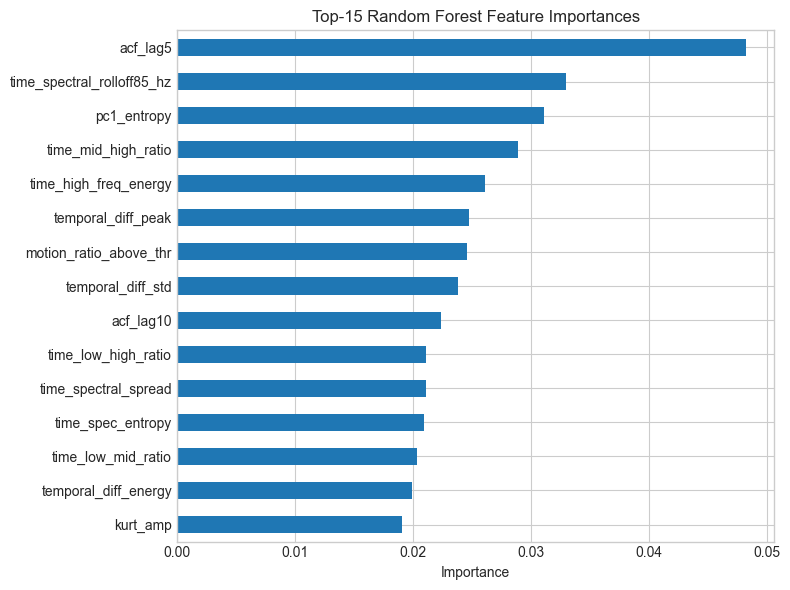

In [20]:
# Optional: inspect most important engineered features (from last trained RF model)
if 'rf' not in globals():
    print('Run one of the experiment cells first so `rf` is available.')
else:
    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    display(importances.head(20).to_frame('importance'))

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind='barh')
    plt.title('Top-15 Random Forest Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()